In [1]:
import os

#add the root directory
os.chdir('../')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from loader import *
import h5py
import matplotlib.ticker as ticker
import matplotlib.transforms as transforms
import matplotlib.lines as mlines
from PCAfold import normalized_variance_derivative, cost_function_normalized_variance_derivative
import re
from matplotlib import gridspec
import matplotlib.cm as cm
from matplotlib.lines import Line2D

from os import listdir
from os.path import isfile, join
from scipy.io import loadmat
from tools import *
import logging
from utils import *

logging.disable(logging.CRITICAL) #disable the logging

# Supplementary material S2.2.3: Encoder-decoder with linear vs. log decoded QoIs on flamelet dataset

In [3]:
path_variance = "data-files/costs/"

name_without = "variance_Tr35a_Yuki_v2_noLog_R1_s4-bw_-6_2_100-dataset_flamelet-Yuki-v2.npy"
name_with = "variance_Tr35a_Yuki_v2_linLog_R1_s8-bw_-6_2_100-dataset_flamelet-Yuki-v2.npy"

penalty_function = 'log-sigma-over-peak'
power = 4
vertical_shift = 1

variance_without = np.load(f"{path_variance}{name_without}", allow_pickle=True).item()
variance_with = np.load(f"{path_variance}{name_with}", allow_pickle=True).item()

(derivative_without, bandwidth_values_without, max_derivative_without) = normalized_variance_derivative(variance_without)
(derivative_with, bandwidth_values_with, max_derivative_with) = normalized_variance_derivative(variance_with)

keys = ['H2O2', 'H2O', 'H2', 'HO2', 'N2O', 'NO2', 'NO', 'O2', 'OH', 'T', 'PV1']

costsWithout = cost_function_normalized_variance_derivative(variance_without,
                                                            penalty_function=penalty_function,
                                                            power=power,
                                                            vertical_shift=vertical_shift,
                                                            norm=None)
costsWith = cost_function_normalized_variance_derivative(variance_with,
                                                            penalty_function=penalty_function,
                                                            power=power,
                                                            vertical_shift=vertical_shift,
                                                            norm=None)

MSEWithout = np.load("paper/data/MSE_QoIs_val_NN_Tr35a_Yuki_v2_noLog_R1_s4_flamelet-Yuki-v2_s7_epo500_lr0.01_scaleManifoldFalse.npy")
MSEWith = np.load("paper/data/MSE_QoIs_val_NN_Tr35a_Yuki_v2_linLog_R1_s8_flamelet-Yuki-v2_s7_epo500_lr0.01_scaleManifoldFalse.npy")

In [4]:
keys = ['H2O2', 'H2O', 'H2', 'HO2', 'N2O', 'NO2', 'NO', 'O2', 'OH', 'T', '$\dot{\omega}_{\mathrm{PV}}$']
keys = [k.replace("2", "$_2$") for k in keys]

greys = cm.get_cmap('Greys')

# Convert to numpy arrays
MSE_without = np.array(MSEWithout)
MSE_with    = np.array(MSEWith)
Cost_without = np.array(costsWithout)
Cost_with    = np.array(costsWith)
features = np.array(keys)

# Compute difference in MSE (absolute change)
delta_MSE = np.abs(np.log(MSE_with) - np.log(MSE_without))

# Sort features by delta_MSE (largest first)
order = np.argsort(delta_MSE)

# Reorder all arrays
features_sorted = features[order]
MSE_without_sorted = MSE_without[order]
MSE_with_sorted = MSE_with[order]
Cost_without_sorted = Cost_without[order]
Cost_with_sorted = Cost_with[order]

# Sub-line vertical offsets
subline_offset = 0.15

C:\Windows\Temp\ipykernel_23596\1233464903.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')


C:\Windows\Temp\ipykernel_23596\2870035713.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')


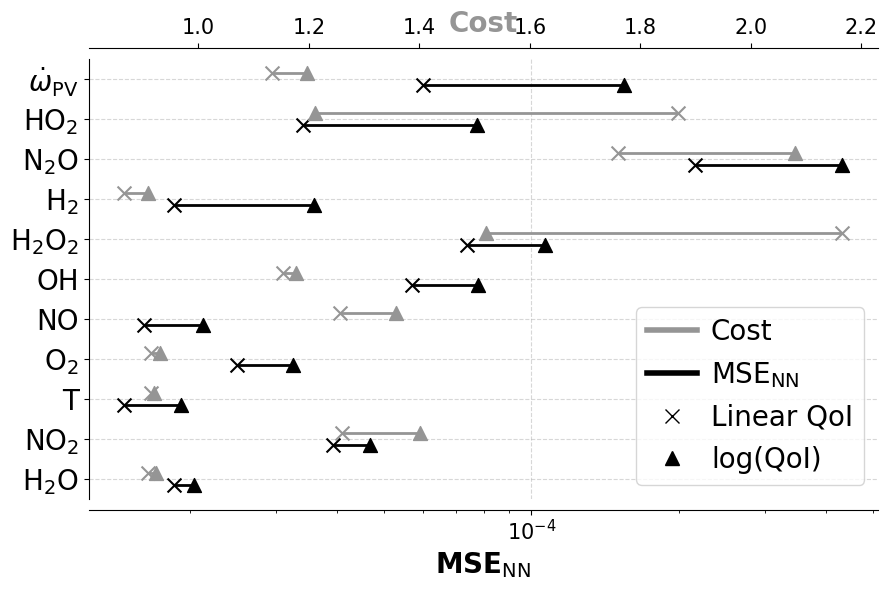

In [5]:
save = False
pathSave = f"C:/Users/Admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/Flamelet-Yuki/"
nameSave = f"Suppl. mat. - flamelet Yuki v2 - linear vs. log QoIs"

def add_panel_label(ax, label, x_offset=-0.12, y_offset=1.08, fontsize=18):
    ax.text(
        x_offset, y_offset,
        label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight="bold",
        va="top",
        ha="left",
        clip_on=False
    )

def plot_left_panel(ax_mse):
    greys = cm.get_cmap('Greys')

    ax_cost = ax_mse.twiny()

    for i, feature in enumerate(features_sorted):
        y_center = i

        # --- MSE ---
        y = y_center - subline_offset
        ax_mse.plot([MSE_without_sorted[i], MSE_with_sorted[i]], [y, y],
                    color="k", linewidth=2)
        ax_mse.scatter(MSE_without_sorted[i], y, color="k", marker="x", s=100, zorder=4)
        ax_mse.scatter(MSE_with_sorted[i], y, color="k", marker="^", s=100, zorder=5)

        # --- Cost ---
        y = y_center + subline_offset
        ax_cost.plot([Cost_without_sorted[i], Cost_with_sorted[i]], [y, y],
                     color=greys(0.5), linewidth=2)
        ax_cost.scatter(Cost_without_sorted[i], y, color=greys(0.5), marker="x", s=100)
        ax_cost.scatter(Cost_with_sorted[i], y, color=greys(0.5), marker="^", s=100)

    ax_mse.set_yticks(range(len(features_sorted)))
    ax_mse.set_yticklabels(features_sorted, fontsize=20)

    ax_mse.set_xlabel("MSE$_{\mathrm{NN}}$", fontsize=20, fontweight="bold")
    ax_cost.set_xlabel("Cost", fontsize=20, color=greys(0.5),
                       labelpad=-10, fontweight="bold")

    ax_mse.set_xscale("log")
    #ax_cost.set_xscale("log")

    ax_mse.grid(axis='both', linestyle='--', alpha=0.5)
    ax_mse.tick_params(axis="x", labelsize=15)
    ax_cost.tick_params(axis="x", labelsize=15)

    ax_mse.set_ylim(-0.5, len(features_sorted) - 0.5)

    # Spines
    ax_mse.spines['top'].set_visible(False)
    ax_mse.spines['right'].set_visible(False)
    ax_cost.spines['right'].set_visible(False)
    ax_cost.spines['left'].set_visible(False)
    ax_cost.spines['bottom'].set_visible(False)

    offset = 8
    ax_mse.spines['bottom'].set_position(('outward', offset))
    ax_cost.spines['top'].set_position(('outward', offset))

    # Legend (unchanged)
    legend_elements = [
        Line2D([0], [0], color=greys(0.5), linestyle="-", lw=4, label="Cost"),
        Line2D([0], [0], color="k", linestyle="-", lw=4, label="MSE$_{\mathrm{NN}}$"),
        Line2D([0], [0], color="k", marker="x", lw=0, markersize=10, label="Linear QoI"),
        Line2D([0], [0], color="k", marker="^", lw=0, markersize=10, label="log(QoI)")
    ]
    ax_mse.legend(handles=legend_elements, fontsize=20,
                  loc="lower right", handletextpad=0.5, handlelength=1.8)

fig, ax_left = plt.subplots(figsize=(9, 6))

keys = ['NO2', 'HO2', 'H2O']
nameCols = ['NO$_2$', 'HO$_2$', 'H$_2$O']
keysYaxis = [r"$Y_{NO}$"+ " [\u2014]", r"$Y_{H_2O_2}$"+ " [\u2014]",r"$\dot{\omega}_{\mathrm{PV}}$"+ " [1/s]"]

plot_left_panel(ax_left)

plt.tight_layout()

if save:
    plt.savefig(pathSave + nameSave + ".png", dpi=1000, bbox_inches="tight")

plt.show()

## Show costs vs MSE for different seeds

In [6]:
namesWithout_flamelet = ["35a_Yuki_v2_noLog_R1"]
namesWith_flamelet = ["35a_Yuki_v2_linLog_R1"]

MSE_NN_without_flamelet = []
MSE_NN_with_flamelet = []

path_MSE_NN = "paper/data/"

my_seed = 7
lr = 0.01

for nameWithout, nameWith in zip(namesWithout_flamelet, namesWith_flamelet):
    MSE_NN_without_flamelet.append(np.load(f"{path_MSE_NN}MSE_val_NN_Tr{nameWithout}_flamelet-Yuki-v2_s{my_seed}.npy"))
    MSE_NN_with_flamelet.append(np.load(f"{path_MSE_NN}MSE_val_NN_Tr{nameWith}_flamelet-Yuki-v2_s{my_seed}.npy"))

MSE_NN_without_flamelet = np.array(MSE_NN_without_flamelet).flatten().tolist()
MSE_NN_with_flamelet = np.array(MSE_NN_with_flamelet).flatten().tolist()

# remove outliers
MSE_NN_without_flamelet.pop(0)

names_without_flamelet = ["35a_Yuki_v2_noLog_R1"] 
names_with_flamelet = ["35a_Yuki_v2_linLog_R1"]

cost_avg_without_flamelet = []
cost_avg_with_flamelet = []

cost_PVsource_without_flamelet = []
cost_PVsource_with_flamelet = []

for i in range(len(names_with_flamelet)):
    for j in range(10):
        
        CostsW_flamelet = np.load(f"data-files/costs/costs_Tr{names_without_flamelet[i]}_s{j}-bw_-6_2_100-p_4-ver_sh_1-dataset_flamelet-Yuki-v2.npy")
        Costs_flamelet = np.load(f"data-files/costs/costs_Tr{names_with_flamelet[i]}_s{j}-bw_-6_2_100-p_4-ver_sh_1-dataset_flamelet-Yuki-v2.npy")

        cost_avg_without_flamelet.append(compute_avg(CostsW_flamelet))
        cost_avg_with_flamelet.append(compute_avg(Costs_flamelet))

        cost_PVsource_without_flamelet.append(CostsW_flamelet[-1])
        cost_PVsource_with_flamelet.append(Costs_flamelet[-1])

#remove outliers
#with: remove index 0
cost_avg_without_flamelet.pop(0)

cost_PVsource_without_flamelet.pop(0)

5.576629709821234

C:\Windows\Temp\ipykernel_23596\3564677344.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')
C:\Windows\Temp\ipykernel_23596\3564677344.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(MSE_NN_without_flamelet, cost_avg_without_flamelet, label="Linear QoIs",
C:\Windows\Temp\ipykernel_23596\3564677344.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  P

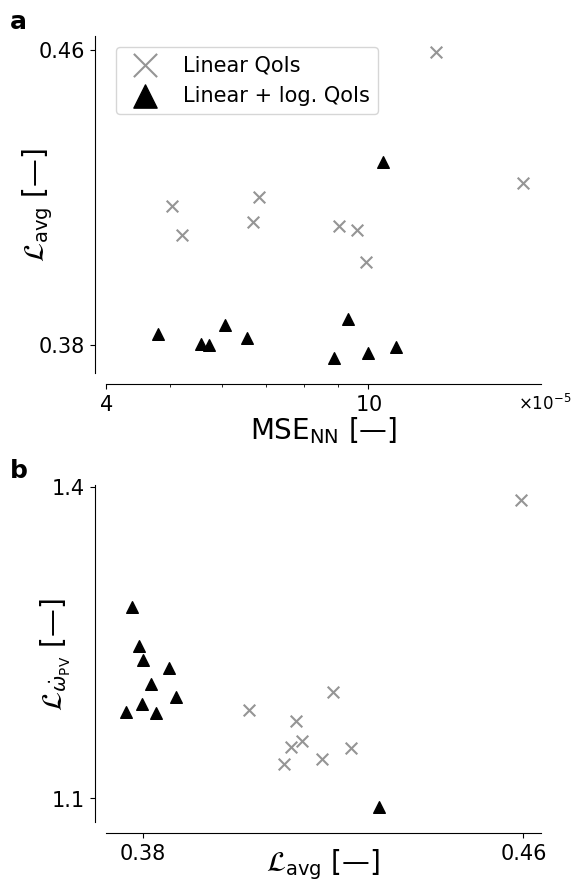

In [9]:
save = True
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/Flamelet-Yuki/"
name = f"Suppl. mat. - flamelet Yuki v2 - MSE vs cost - linear vs. log QoIs"

fig, ax = plt.subplots(
    2, 1,
    figsize=(6, 9),
    sharex=False,
    sharey=False
)

def plot_figure_1(ax):
    size_marker = 70
    greys = cm.get_cmap('Greys')

    # --- Top subplot (a) ---
    ax[0].scatter(MSE_NN_without_flamelet, cost_avg_without_flamelet, label="Linear QoIs",
                  c=greys(0.5), marker="x", s=size_marker)
    ax[0].scatter(MSE_NN_with_flamelet, cost_avg_with_flamelet, label="Linear + log. QoIs",
                  c="k", marker="^", s=size_marker)

    ax[0].set_xlabel(r'$\mathrm{MSE}_{\mathrm{NN}}$ [—]', fontsize=20, labelpad=0)
    ax[0].set_ylabel(r'$\mathcal{L}_{\mathrm{avg}}$ [—]', fontsize=20, labelpad = -12)
    ax[0].legend(fontsize=15, scatterpoints=1, markerscale=2)
    ax[0].set_xscale("log")
    ax[0].set_xticks([0.00004, 0.0001])
    ax[0].set_xticklabels([r'$4$', r'$10$'], fontsize=15)
    ax[0].xaxis.set_minor_formatter(ticker.NullFormatter())
    ax[0].set_yticks([0.38, 0.46])
    ax[0].tick_params(axis='y', labelsize=15)
    ax[0].xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x*10**5:g}")
    )
    ax[0].text(1.07, -0.09, r'$\times 10^{-5}$',
               transform=ax[0].transAxes, fontsize=12,
               va='center', ha='right')

    # --- Bottom subplot (b) ---
    ax[1].scatter(cost_avg_without_flamelet, cost_PVsource_without_flamelet,
                  c=greys(0.5), marker="x", s=size_marker)
    ax[1].scatter(cost_avg_with_flamelet, cost_PVsource_with_flamelet,
                  c="k", marker="^", s=size_marker)

    ax[1].set_xlabel(r'$\mathcal{L}_{\mathrm{avg}}$ [—]', fontsize=20, labelpad=-12)
    ax[1].set_ylabel(r'$\mathcal{L}_{\dot{\omega}_{\mathrm{PV}}}$ [—]', fontsize=20, labelpad = -15)
    ax[1].set_xticks([0.38, 0.46])
    ax[1].set_yticks([1.1, 1.4])
    ax[1].tick_params(axis='both', labelsize=15)

    # Spine cleanup
    for a in ax:
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        a.spines['left'].set_position(('outward', 8))
        a.spines['bottom'].set_position(('outward', 8))
        a.tick_params(direction="out")

    ax[0].set_xticklabels([r'$4$', r'$10$'], fontsize=15)


def add_panel_label(ax, label, x_offset=-0.12, y_offset=1.08, fontsize=18):
    ax.text(
        x_offset, y_offset,
        label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight="bold",
        va="top",
        ha="left",
        clip_on=False
    )


# Plot panels a and b
plot_figure_1(ax)

add_panel_label(ax[0], "a", x_offset = -0.22)
add_panel_label(ax[1], "b", x_offset = -0.22)

plt.tight_layout()

if save:
    plt.savefig(pathSave + name + ".png", dpi=1000, bbox_inches="tight")
    plt.savefig(pathSave + name + ".pdf", bbox_inches="tight")

plt.show()